In [1]:
from IPython.display import HTML
HTML("<style>.container{width:100%!important;margin:auto}div.cell,div.input_area{padding:2px;margin:0}div.output_wrapper{padding:0;margin:0}</style>")

# Probability: From Coin Flips to AI
Welcome! Probability is the mathematical language of uncertainty. It helps us quantify how likely an event is to happen. In this notebook, we'll start from simple intuition (flipping coins), build up to conditional probability, discover Bayes' Theorem, and see exactly how these concepts power modern Machine Learning classifiers!

Let's begin by importing a few Python libraries we'll use to run interactive experiments and plot charts.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random

# Set a random seed so our experiments are reproducible
np.random.seed(42)
random.seed(42)

print("Setup complete! Libraries imported successfully.")

Setup complete! Libraries imported successfully.


---

## Module 1: The Foundations of Probability
Think of probability as a fraction or a ratio between $0$ and $1$ (or $0\%$ to $100\%$). 
* A probability of **0** means an event is *impossible* (e.g., rolling an 8 on a standard 6-sided die).
* A probability of **1** means an event is *certain* (e.g., the sun rising tomorrow).

### Core Definitions:
1. **Sample Space ($S$):** The set of *all possible outcomes*. For a coin flip, $S = \{\text{Heads}, \text{Tails}\}$. For a die roll, $S = \{1, 2, 3, 4, 5, 6\}$.
2. **Event ($A$):** The specific outcome or collection of outcomes we care about (e.g., "rolling an even number").

The classical formula for probability when all outcomes are equally likely is:

$$P(A) = \frac{\text{Number of favorable outcomes}}{\text{Total number of possible outcomes}}$$

### The Law of Large Numbers
If we flip a fair coin 10 times, we might get 7 Heads and 3 Tails just by random luck ($70\%$ Heads). But if we flip that same coin 10,000 times, the percentage of Heads will get incredibly close to the true mathematical probability of $50\%$ ($0.5$). 

Let's run a simulation to watch this law in action!

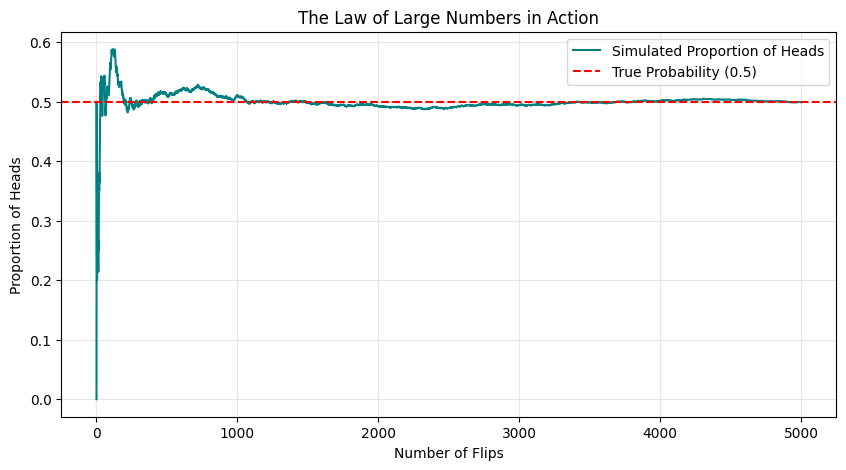

Final calculated probability after 5,000 flips: 0.4992


In [3]:
def simulate_coin_flips(n_flips):
    # 0 represents Tails, 1 represents Heads
    flips = np.random.choice([0, 1], size=n_flips)
    
    # Calculate the running proportion of Heads
    running_heads = np.cumsum(flips)
    trials = np.arange(1, n_flips + 1)
    running_proportion = running_heads / trials
    
    return trials, running_proportion

# Simulate 5,000 coin flips
trials, proportions = simulate_coin_flips(5000)

# Plotting the results
plt.figure(figsize=(10, 5))
plt.plot(trials, proportions, label="Simulated Proportion of Heads", color='teal')
plt.axhline(y=0.5, color='red', linestyle='--', label="True Probability (0.5)")
plt.xlabel("Number of Flips")
plt.ylabel("Proportion of Heads")
plt.title("The Law of Large Numbers in Action")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Final calculated probability after 5,000 flips: {proportions[-1]:.4f}")

---

## Module 2: When Events Interact (Independence vs. Mutual Exclusivity)
Before we look at how incoming information shifts our calculations, we need to understand how different events interact with each other. Two concepts often trip people up: **Independence** and **Mutual Exclusivity**. They sound similar, but mathematically they are completely different!

### A. Independent Events (No Influence)
Two events are independent if the occurrence of one event has **absolutely zero impact** on the probability of the other occurring. 

* **Example:** You flip a coin and get Heads (Event A), and then you roll a 6-sided die and get a 4 (Event B). The coin couldn't care less about the die!
* **The Rule:** If events are independent, the probability of both happening together ($A \cap B$) is simply found by multiplying their individual probabilities:

$$P(A \cap B) = P(A) \cdot P(B)$$

### B. Mutually Exclusive Events (Can't Happen Together)
Two events are mutually exclusive if they **cannot happen at the same time**. If one happens, the other becomes instantly impossible.

* **Example:** Turning left and turning right at the exact same split intersection. Or pulling a single card from a deck and having it be *both* a Heart and a Spade. 
* **The Rule:** Because they cannot overlap, the probability of them happening together is exactly zero:

$$P(A \cap B) = 0$$

---

## Module 3: Conditional Probability (The Game Changes)
What happens when two events are *neither* independent nor mutually exclusive? They are linked! This is where we acquire new information that shifts our entire baseline context. 

**Conditional Probability** asks: *"What is the probability of event $A$ happening, GIVEN that we already know event $B$ has definitely occurred?"*

We write this mathematically as: $P(A|B)$ (read as "Probability of A given B").

### The Formula:
$$P(A|B) = \frac{P(A \cap B)}{P(B)}$$

> **Connection Note:** If two events were completely *independent*, knowing that $B$ happened wouldn't change anything, so $P(A|B)$ would just equal $P(A)$. If they were *mutually exclusive*, knowing $B$ happened means $A$ is impossible, so $P(A|B)$ would equal $0$. 

### The Visual Framework
Let's see what happens when the events are connected. Imagine a classroom of 100 students:
* 60 students like **Video Games** (Event $B$)
* 20 students like **Chess** (Event $A$)
* 15 students like **Both** ($A \cap B$)

If I pick a student completely at random from the entire class of 100, the probability they like chess is:
$$P(\text{Chess}) = \frac{20}{100} = 20\%$$

But what if I say: *"Hey, I picked a student, and they told me they love playing Video Games."* 

Suddenly, our sample space shrinks from 100 down to **just the 60 video game players**. Out of those 60 remaining players, how many like chess? 15!

$$P(\text{Chess} | \text{Video Games}) = \frac{15}{60} = 0.25 \text{ (or } 25\%)$$

Because $25\%$ is different from our starting $20\%$, we know that liking chess and playing video games are dependent events in this classroom! Let's look at a quick simulated breakdown of this group of students to verify our intuition.

In [4]:
# Generate a synthetic dataset representing our 100 students
students = []
for _ in range(15):  students.append({'Video_Games': 1, 'Chess': 1}) # Both
for _ in range(45):  students.append({'Video_Games': 1, 'Chess': 0}) # Only Games
for _ in range(5):   students.append({'Video_Games': 0, 'Chess': 1}) # Only Chess
for _ in range(35):  students.append({'Video_Games': 0, 'Chess': 0}) # Neither

df_students = pd.DataFrame(students)

# Calculate conditional probability using our dataframe
total_video_gamers = df_students[df_students['Video_Games'] == 1]
gamers_who_play_chess = total_video_gamers[total_video_gamers['Chess'] == 1]

p_chess_given_games = len(gamers_who_play_chess) / len(total_video_gamers)

print(f"Total students who like Video Games: {len(total_video_gamers)}")
print(f"Out of those, how many play Chess: {len(gamers_who_play_chess)}")
print(f"P(Chess | Video Games) = {p_chess_given_games:.2%}")

Total students who like Video Games: 60
Out of those, how many play Chess: 15
P(Chess | Video Games) = 25.00%


---

## Module 4: Bayes' Theorem (Flipping the Perspective)
Sometimes we know the probability of **Evidence given a Hypothesis**, but what we *actually* want to discover is the probability of the **Hypothesis given the Evidence**. 

Bayes' Theorem provides the exact bridge to flip that conditional probability upside down:

$$P(\text{Hypothesis} | \text{Evidence}) = \frac{P(\text{Evidence} | \text{Hypothesis}) \cdot P(\text{Hypothesis})}{P(\text{Evidence})}$$

To understand how this formula works, we need to decode its four specific components. Let's look at them using an easy high school scenario.

### The Breakdown: Prior, Likelihood, Evidence, and Posterior

$$\text{Posterior} = \frac{\text{Likelihood} \times \text{Prior}}{\text{Evidence}}$$

1. **The Prior ($P(\text{Hypothesis})$):** Your starting baseline guess *before* looking at any new clues. How likely is this hypothesis on an average day?
2. **The Likelihood ($P(\text{Evidence} | \text{Hypothesis})$):** If your hypothesis is actually true, how common or expected is the clue you just saw?
3. **The Evidence ($P(\text{Evidence})$):** The overall, total probability of seeing this clue happen across all situations, whether your hypothesis is true or false. It acts as a **normalization factor** (a scaling tool) to make sure our final percentage fits between $0\%$ and $100\%$.
4. **The Posterior ($P(\text{Hypothesis} | \text{Evidence})$):** The final updated probability. This is what you calculate *after* combining your old baseline guess with your new clue.

---

### A Simple Concrete Example: The Comic Book Detective
Imagine a school of 100 students. You find a loose pages from a **Comic Book** on the hallway floor (this is your **Evidence**). You want to guess if it dropped from a **Comic Fan's** backpack (your **Hypothesis**).

Here is what you know about the school:
* **The Prior:** Only 10 students are actual hardcore Comic Fans. ($P(\text{Fan}) = \frac{10}{100} = 0.10$). The other 90 are not.
* **The Likelihood:** If someone is a Comic Fan, there is an $80\%$ chance they carry a comic to school. ($P(\text{Comic} | \text{Fan}) = 0.80$).
* **The Alternate Likelihood:** If someone is *not* a fan, they might still occasionally have a comic book (maybe a friend lent it to them). Let's say this happens $20\%$ of the time. ($P(\text{Comic} | \text{Not Fan}) = 0.20$).

#### Let's solve it step-by-step:

**Step 1: Find the total Evidence ($P(\text{Comic})$)**
How many total kids carry comics? 
* From the fans: $10 \text{ fans} \times 80\% = 8 \text{ kids}$
* From the non-fans: $90 \text{ non-fans} \times 20\% = 18 \text{ kids}$
* Total Evidence = $8 + 18 = 26 \text{ kids total.}$ So, $P(\text{Comic}) = \frac{26}{100} = 0.26$.

**Step 2: Apply Bayes' Theorem to find the Posterior**
$$\text{Posterior} = \frac{\text{Likelihood} \times \text{Prior}}{\text{Evidence}} = \frac{0.80 \times 0.10}{0.26} = \frac{0.08}{0.26} \approx 30.7\%$$

Even though a comic fan is highly likely to have a comic book ($80\%$), finding a comic book on the floor only means there is a **$30.7\%$ chance** it belongs to a hardcore fan. Why? Because the non-fan group is so much larger that they end up dropping more total comic books overall!

Let's plug these exact numbers into Python to calculate it:

In [5]:
# Our concrete student data variables
p_fan = 0.10          # Prior
p_not_fan = 0.90      # Remaining background population

p_comic_given_fan = 0.80      # Likelihood
p_comic_given_not_fan = 0.20  # Alternate Likelihood

# Step 1: Calculate total Evidence denominator
p_comic = (p_comic_given_fan * p_fan) + (p_comic_given_not_fan * p_not_fan)

# Step 2: Calculate Posterior
p_fan_given_comic = (p_comic_given_fan * p_fan) / p_comic

print(f"Total Evidence parameter P(Comic): {p_comic:.2%}")
print(f"Posterior Probability P(Fan | Comic): {p_fan_given_comic:.2%}")

Total Evidence parameter P(Comic): 26.00%
Posterior Probability P(Fan | Comic): 30.77%


---

## Module 5: Connection to Machine Learning: What AI Skips and Ignores

When Machine Learning models use Bayes' Theorem to classify objects (like sorting text into "Spam" vs. "Normal Email"), engineers use two brilliant mathematical shortcuts to handle real-world data. ML Ignores the Evidence Denominator and  the Prior (if required).

#### 1. Why ML Ignores the Evidence Denominator ($P(\text{Evidence})$)
Calculating the exact total probability of the evidence can be incredibly difficult when you have thousands of **variable** (also called a "feature"). For example, if a new email arrives containing 50 words, that means the AI has to evaluate 50 individual variables simultaneously ($x_1 = \text{"free"}$, $x_2 = \text{"money"}$, $x_3 = \text{"click"}$, etc.). To calculate the true Bayes denominator, $P(\text{Evidence})$, the computer would have to figure out the exact probability of seeing that specific combination of 50 words appearing together across every single email ever sent in human history. Calculating this absolute total probability is practically impossible when dealing with so many moving variables!

Luckily, the AI doesn't actually need to calculate the exact denominator to do its job. Why? Because the AI is making a **comparison**. It just wants to know which score is bigger!


Imagine you receive a short email that contains the variables *"Winner"*. The AI calculates two fractions to compare them:

$$\text{Spam Score} = \frac{P(\text{"Winner"} | \text{Spam}) \cdot P(\text{Spam})}{P(\text{"Winner"})}$$

$$\text{Normal Email Score} = \frac{P(\text{"Winner"} | \text{Normal}) \cdot P(\text{Normal})}{P(\text{"Winner"})}$$

Notice that the bottom number, $P(\text{"Winner"})$, is **exactly identical** in both equations. 

Let's look at a quick numerical example to see why this matters:
* Suppose the top part (the numerator) for Spam calculates to **0.08**.
* Suppose the top part for Normal Email calculates to **0.02**.
* Let's say the true, incredibly hard-to-calculate denominator is **0.10**.

If we do the full math:
* True Spam Probability = $\frac{0.08}{0.10} = 80\%$
* True Normal Probability = $\frac{0.02}{0.10} = 20\%$

**Spam wins the race!**

But what if we completely ignore that bottom $0.10$ and just look at the top numbers?
* Spam Top Score = **0.08**
* Normal Top Score = **0.02**

**Spam still wins!** 

Because the bottom number scales both sides equally, it never changes *who* wins the comparison. By dropping the denominator completely, the AI saves massive amounts of computer processing power. It looks strictly at which top number is bigger and drops the email into the winning folder. 

This is why the final mathematical step in machine learning classification is often written with a proportional symbol ($\propto$) instead of an equals sign:

$$P(\text{Category} | \text{Evidence}) \propto P(\text{Evidence} | \text{Category}) \cdot P(\text{Category})$$

#### 3. When ML Ignores the Prior ($P(\text{Hypothesis})$)
Sometimes, an AI system has no historical data to know how common a category is beforehand. For example, if a brand-new email service starts up, it doesn't know what percentage of incoming mail will be spam. 

If you don't know the baseline rates, the fairest starting point is to assume all categories are equally likely (e.g., a $50\%$ chance of Spam, and a $50\%$ chance of Normal Email). 

When you set all Priors to the exact same value, the Prior cancels out and stops affecting the comparison. In that specific scenario, the AI's decision depends entirely on the **Likelihood** ($P(\text{Evidence} | \text{Category})$). Selecting the winning option based strictly on which category has the highest likelihood of generating that evidence is a core concept in machine learning called **Maximum Likelihood Estimation (MLE)**!